## Clase: Análisis Multivariable con Clustering
**Duración:** 1 hora 40 minutos  
**Módulo:** Identificación de variables clave de rentabilidad y segmentación de clientes  
**Objetivo de la sesión:** Utilizar técnicas de clustering para identificar segmentos significativos en los datos financieros y de clientes, y analizar su relación con KPIs de rentabilidad.

### Caso base: Gabu, startup de supervisión de niños mientras juegan online
**Situación:** La empresa desea entender mejor a sus clientes y categorizar de acuerdo a datos demograficos para personalizar campañas de adquisición de clientes y aumentar el uso de la plataforma.
**Datos:** Datos anonimizados de usuarios, incluyendo edad del niño, sexo, nivel educativo del padre/madre, frecuencia de uso, ticket promedio, etc.

- customer_id: ID del cliente, padre o tutor del niño.
- kid_id: ID del niño.
- kids_age: Edad del niño.
- kids_sex: Sexo del niño. 0 niño, 1 niña.
- family_income: Ingreso anual de la familia
- subscription_type: Tipo de suscripción (Básica, Premium, Familiar).
- monthly_fee: Tarifa mensual pagada por el usuario en USD. En el plan familiar se cobra $35 USD por toda la familia.
- avg_session_time: Promedio de tiempo de sesión en minutos.
- customer_support_tickets: Tickets de soporte abiertos por el cliente.
- issue_resolution_time: Tiempo promedio de resolución de tickets en horas.
- tenure: Meses que han pasado desde que el niño se unió a Gabu.
- signup_channel: Canal de adquisición del padre o tutor.
- total_sessions: Número total de sesiones en la plataforma.
- churn: 1 si el cliente canceló su suscripción, 0 si sigue activo.

**¿Que variables deberíamos de usar?**

---

### Parte 1: Introducción a Análisis Multivariable y Clustering (20 min)

- **Concepto de análisis multivariable:** exploración de relaciones entre múltiples variables.
- **Concepto de clustering:** técnica de aprendizaje no supervisado para segmentación.
- **Aplicaciones en negocios:** segmentación de clientes, detección de patrones de consumo, personalización de estrategias.

**Ejemplo breve:** visualización 2D de datos ficticios y agrupamiento por colores (usando Seaborn y KMeans).

In [ ]:
%pip install scikit-learn

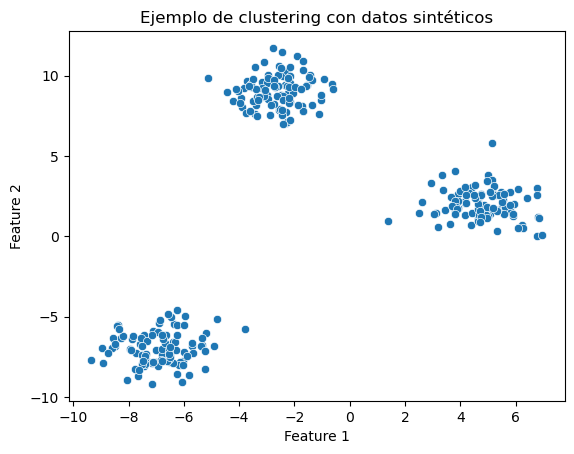

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Creamos un dataset de ejemplo
X_blob, y_blob = make_blobs(n_samples=300, centers=3, random_state=42)
X_prueba = pd.DataFrame(X_blob)

# Visualizamos
sns.scatterplot(x=X_prueba[0], y=X_prueba[1])a
plt.title("Ejemplo de clustering con datos sintéticos")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

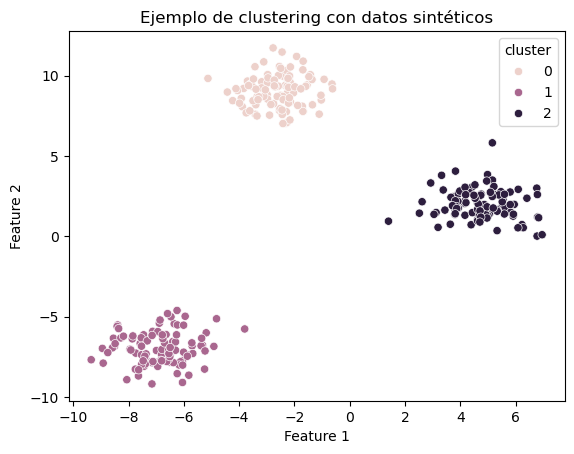

In [4]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3, random_state=42)
X_prueba.columns = X_prueba.columns.astype(str)
X_prueba["cluster"] = model.fit_predict(X_prueba)

sns.scatterplot(x=X_prueba['0'], y=X_prueba['1'], hue=X_prueba["cluster"])
plt.title("Ejemplo de clustering con datos sintéticos")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

---

### Parte 2: Preparación y Normalización de Datos (20 min)
- Limpieza de datos (nulos, valores extremos, codificación de categóricas).
- Normalización con `StandardScaler`.
- Reducción de dimensiones para visualización con PCA (opcional).

**Actividad guiada:** Limpieza y preparación del dataset de Gabu en Jupyter Notebook.

Usaremos los features ['kids_age', 'kids_sex', 'family_income', 'avg_session_time', 'avg_session_time']


In [3]:
df = pd.read_csv("data/gabu_dataset_2.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1317 entries, 0 to 1316
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1317 non-null   int64  
 1   customer_id               1317 non-null   int64  
 2   kid_id                    1317 non-null   object 
 3   kids_age                  1251 non-null   float64
 4   kids_sex                  1251 non-null   float64
 5   family_income             1252 non-null   float64
 6   subscription_type         1317 non-null   object 
 7   monthly_fee               1317 non-null   float64
 8   avg_session_time          1251 non-null   float64
 9   customer_support_tickets  1317 non-null   int64  
 10  issue_resolution_time     1317 non-null   float64
 11  signup_channel            1317 non-null   object 
 12  churn                     1317 non-null   int64  
 13  tenure                    1317 non-null   int64  
 14  total_se

In [9]:
df['kids_sex'].unique()

array([ 0.,  1.,  2., nan,  3.])

In [5]:
df = df.drop(columns=['Unnamed: 0'])

In [13]:
features = ['kids_age', 'kids_sex', 'family_income', 'avg_session_time']
categorical_features = ['kids_sex']

In [15]:
df[features].describe()

,kids_age,kids_sex,family_income,avg_session_time
count,1251.000000,1251.000000,1252.000000,1251.000000
mean,8.522782,0.163869,92332.268371,24.396650
std,2.277209,0.428399,101851.915892,12.953069
min,2.000000,0.000000,25000.000000,11.200972
25%,7.000000,0.000000,50000.000000,18.115883
50%,9.000000,0.000000,75000.000000,24.663714
75%,10.000000,0.000000,100000.000000,27.699449
max,25.000000,3.000000,1000000.000000,139.418161


#### Limpieza de datos

In [17]:
# Copia del DataFrame original
df_clean = df.copy()

# --- 1. kids_age ---
# Mantener edades razonables (niños de 3 a 18 años)
df_clean = df_clean[(df_clean['kids_age'] >= 3) & (df_clean['kids_age'] <= 18)]

# --- 2. kids_sex ---
# Solo permitir 0 (niño) y 1 (niña)
df_clean = df_clean[df_clean['kids_sex'].isin([0, 1]).notna()]

# --- 3. family_income ---
# Eliminar nulos
df_clean = df_clean[df_clean['family_income'].notna()]

# Detectar y eliminar outliers con método percentile
def remove_outliers_using_iqr(df, column, perc=0.05):
    min = df[column].quantile(perc/2)
    max = df[column].quantile(1-perc/2)

    return df[
        (df[column] >= min) &
        (df[column] <= max) &
        (df[column].notna())
    ]

for i in features:
    df_clean = remove_outliers_using_iqr(df_clean, i, 0.05)

df_clean[features].describe()

,kids_age,kids_sex,family_income,avg_session_time
count,1103.000000,1103.000000,1103.000000,1103.000000
mean,8.485947,0.129646,83567.543064,23.321413
std,1.754313,0.336066,41906.545388,5.115931
min,5.000000,0.000000,25000.000000,13.857695
25%,7.000000,0.000000,50000.000000,18.381186
50%,9.000000,0.000000,75000.000000,24.692223
75%,10.000000,0.000000,100000.000000,27.579107
max,12.000000,1.000000,200000.000000,32.198942


#### Estandarizar

In [19]:
numerical_features = [x for x in features if x != 'kids_sex']

# Estandarización
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df_clean[numerical_features]), 
                         columns=numerical_features, 
                         index=df_clean.index)
scaled_df.describe()

,kids_age,family_income,avg_session_time
count,1.103000e+03,1.103000e+03,1.103000e+03
mean,-2.029202e-16,-1.707106e-16,1.771525e-16
std,1.000454e+00,1.000454e+00,1.000454e+00
min,-1.987974e+00,-1.398209e+00,-1.850692e+00
25%,-8.474093e-01,-8.013729e-01,-9.660935e-01
50%,2.931550e-01,-2.045368e-01,2.680710e-01
75%,8.634372e-01,3.922994e-01,8.326198e-01
max,2.004001e+00,2.779644e+00,1.736059e+00


In [21]:
# Verificamos que no hay valores nulos
df_clean['kids_sex'].isna().sum()

0

In [23]:
X_cluster = pd.concat([scaled_df, df_clean['kids_sex']], axis=1)
X_cluster.describe()

,kids_age,family_income,avg_session_time,kids_sex
count,1.103000e+03,1.103000e+03,1.103000e+03,1103.000000
mean,-2.029202e-16,-1.707106e-16,1.771525e-16,0.129646
std,1.000454e+00,1.000454e+00,1.000454e+00,0.336066
min,-1.987974e+00,-1.398209e+00,-1.850692e+00,0.000000
25%,-8.474093e-01,-8.013729e-01,-9.660935e-01,0.000000
50%,2.931550e-01,-2.045368e-01,2.680710e-01,0.000000
75%,8.634372e-01,3.922994e-01,8.326198e-01,0.000000
max,2.004001e+00,2.779644e+00,1.736059e+00,1.000000


#### Visualizar

In [25]:
X_cluster.isna().sum()

kids_age            0
family_income       0
avg_session_time    0
kids_sex            0
dtype: int64

In [27]:
from sklearn.decomposition import PCA

pca = PCA()
pca_result = pca.fit_transform(X_cluster)

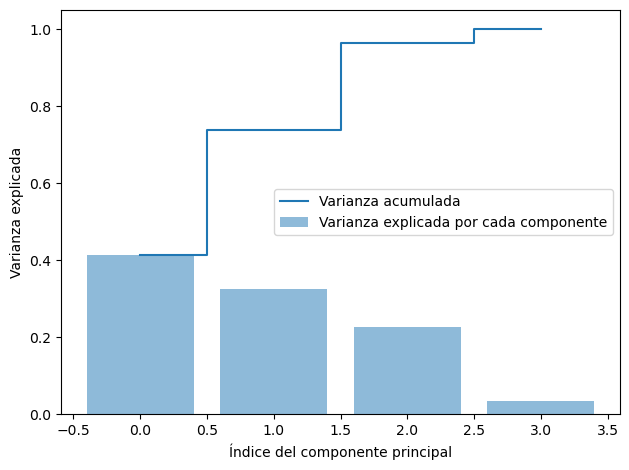

In [31]:
explained_variance = pca.explained_variance_ratio_

cum_sum_eigenvalues = np.cumsum(explained_variance)

plt.bar(range(0,len(explained_variance)), explained_variance, alpha=0.5, align='center', label='Varianza explicada por cada componente')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Varianza acumulada')
plt.ylabel('Varianza explicada')
plt.xlabel('Índice del componente principal')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

¿Qué significa cada componente?

In [33]:
loadings = pd.DataFrame(
    pca.components_.T,  
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X_cluster.columns
)

print(loadings)

                       PC1       PC2       PC3       PC4
kids_age         -0.005009  0.981283 -0.191550  0.019166
family_income     0.704995  0.139616  0.695137 -0.016584
avg_session_time  0.708413 -0.132384 -0.690355  0.063530
kids_sex         -0.033296 -0.008100  0.059197  0.997658


In [32]:
df_clean[['pca_1', 'pca_2', 'pca_3']] = pca_result[:, :3]
pca_result

array([[-1.16091961,  2.12791578,  0.45150626, -0.17820876],
       [-1.50642931,  2.03052432, -0.03671456, -0.16156161],
       [-1.44610519, -1.3495166 ,  0.60337795,  0.77737584],
       ...,
       [ 0.5765289 ,  1.4061155 , -0.30470801, -0.08121328],
       [ 0.42360564, -0.96356251, -0.53251986, -0.09203928],
       [-0.71742964,  1.08884869,  1.06828751, -0.20844119]])

---

### Parte 3: Aplicación de KMeans (30 min)
- Cómo funciona KMeans y su objetivo.
- Elección del número de clusters (`Elbow method`).
- Visualización de resultados.

**Actividad:**
1. Visualizar el método del codo.
2. Establecer los clusters.
3. Graficar los resultados.
4. Analizar las características de cada cluster.

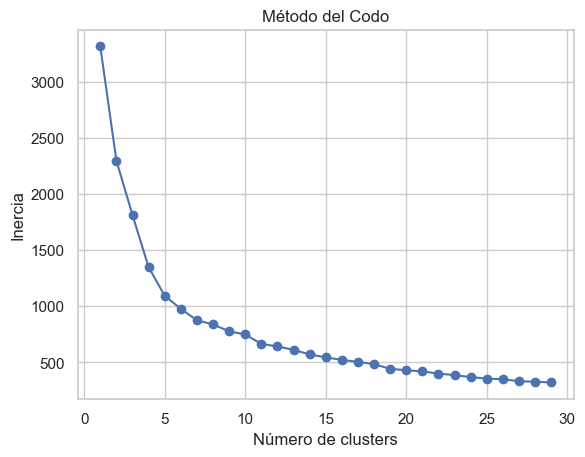

In [42]:

inertia = []
k_range = range(1, 30)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df_clean[['pca_1', 'pca_2', 'pca_3']])
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

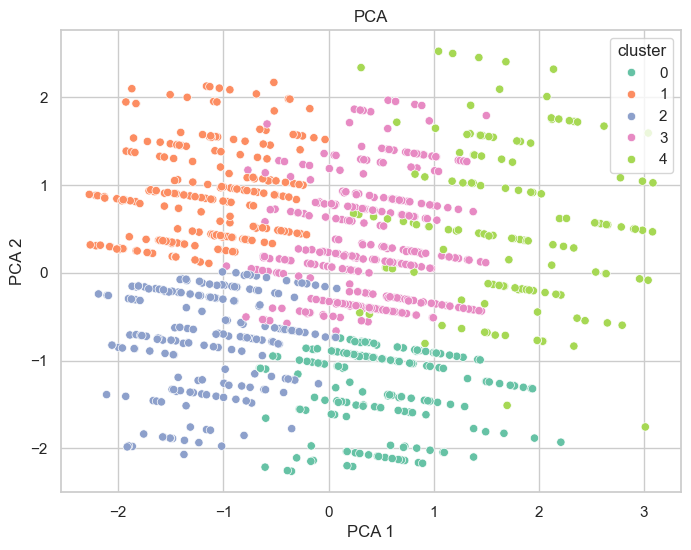

In [43]:
# Aplicamos KMeans con el número de clusters elegido
kmeans = KMeans(n_clusters=5, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(df_clean[['pca_1', 'pca_2', 'pca_3']])

# Reducción de dimensiones para visualizar
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='pca_1', y='pca_2', hue="cluster", palette="Set2")
plt.title("PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

---

### Parte 4: Interpretación de Resultados y Conexión con KPIs (20 min)
- Identificación de perfiles de usuarios.
- Cómo se relacionan los clusters con el LTV (Lifetime Value) u otros KPIs.
- Implicaciones para estrategias de negocio (retención, marketing, precios).

**Discusión guiada:**
- ¿Cuál cluster es más rentable?
- ¿Cuáles deberían recibir incentivos?

#### Identificación de perfiles de usuarios

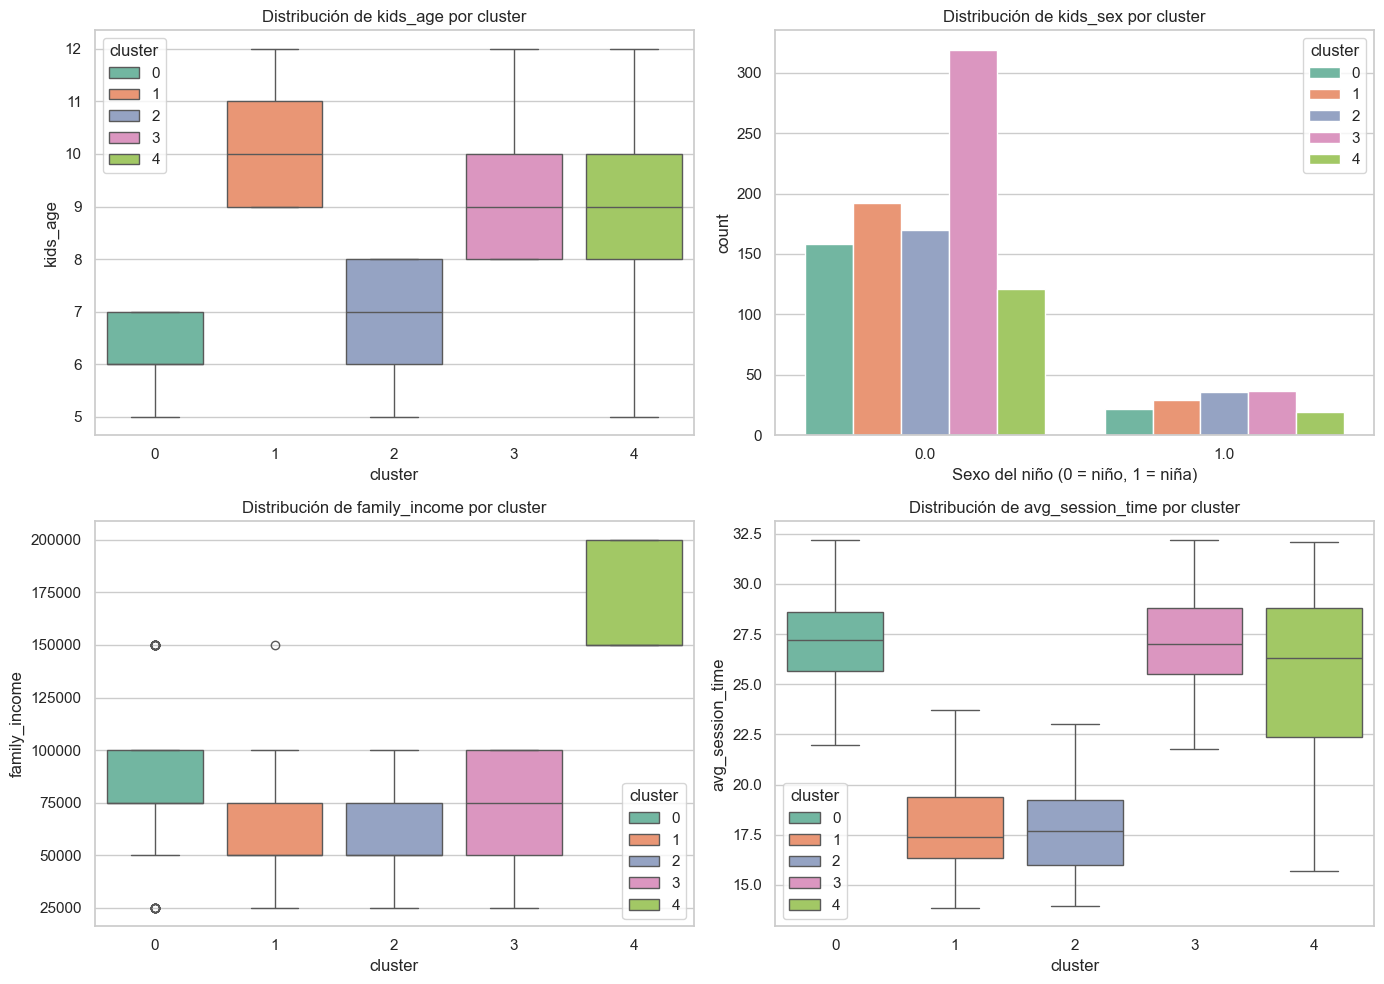

In [44]:
# Configuración general del layout
sns.set(style="whitegrid")
num_cols = 2
num_rows = int(np.ceil(len(features) / num_cols))

plt.figure(figsize=(14, 5 * num_rows))

for i, feature in enumerate(features, 1):
    plt.subplot(num_rows, num_cols, i)

    if feature not in numerical_features:
        # Gráfico de barras para variable categórica
        sns.countplot(data=df_clean, x=feature, hue='cluster', palette='Set2')
        plt.title(f'Distribución de {feature} por cluster')
        plt.xlabel("Sexo del niño (0 = niño, 1 = niña)")
    else:
        # Boxplot para variables numéricas
        sns.boxplot(data=df_clean, x='cluster', y=feature, hue='cluster', palette='Set2')
        plt.title(f'Distribución de {feature} por cluster')

plt.tight_layout()
plt.show()


In [41]:
# Agregamos KPIs por cluster
kpi_cols = ['monthly_fee', 'avg_session_time', 'customer_support_tickets', 'tenure', 'churn']
cluster_summary = df_clean.groupby('cluster')[kpi_cols].mean().round(2)
cluster_summary

,monthly_fee,avg_session_time,customer_support_tickets,tenure,churn
cluster,,,,,
0,11.14,17.70,1.47,5.00,0.41
1,18.46,27.05,1.48,6.82,0.22
2,18.71,27.11,1.49,6.55,0.24
3,11.11,17.71,1.76,5.07,0.43
4,17.77,25.75,1.27,6.66,0.26


---

### Cierre y Reflexión (10 min)
- Beneficios del clustering en contexto empresarial.
- Ventajas y limitaciones.
- Posibles extensiones (DBSCAN, GMM, clustering con embeddings).

---

### Recursos y Referencias
- [Scikit-learn Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [Guía PCA + Clustering](https://rich-d-wilkinson.github.io/MATH3030/part-ii-dimension-reduction-methods.html)
